<a href="https://colab.research.google.com/github/hamed85/ML-challenges/blob/main/Spam_Email_Identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## This code is provided using python 3.6.1 to answer the challenge designed by OneClass.
## Applicant: Hamed Afshari, Role: Machine Learning Engineer, Submission Date: 14/11/2017
##
## The main code ('main.py') imports a pre-made list of email list ('email_training.csv')
## that assigns 0 to the correct emails and 1 to the spams. The features are defined by
## ('feature_gen.py') and the classifiers are defined by ('classifiers.py').
##  The main steps of this project include:
##   1- import the csv file into python;
##   2- Define features by investigating the training dataset as defined in 'feature_gen.py';
##   3- Split training data into training and test sets using K-fold cross-validation method;
##   4- Apply some ML classifiers include Gaussian Naive Bayes (GNB), Logistic Regression (logreg),
##      Multi-Layer Perceptron (MLP), Supporting Vector Machine (SVM) defined in 'classifiers.py';
##   5- Evaluate the performance of ML methods using the accuracy, precision, and recall scores;
##   6- Visualize SVM performance by precision-recall curve, and Receiver Operating Char (ROC) curve;
##   7- Apply the Gaussian Naive Bayes (GNB) to predict labels of emails in 'email_test.csv'. GNB has
##   the best performance among classifiers. The code saves emails and predicted labels in 'solution.csv'.


In [ ]:
## Step 1) import 'email_training.csv' into python 3.6.1:
import csv
import numpy as np

with open('email_training.csv') as file:
  reader = csv.DictReader(file)                # read the csv file as a dictionary ({header : value})
  data = {}
  for row in reader:
    for header, value in row.items():
      try:
        data[header].append(value)
      except KeyError:
        data[header] = [value]

emails = data['email']
labels = data['label']

In [ ]:
## Step 2) Define 7 features by investigating the dataset:

spam_words = ['spam','fake','safe','login','discard','guerrilla','lol','junk','dead','trash','fan','hazard','nomail']

def feature_1(email):  # Feature 1 checks the existence of '@' in the email address
    if '@' in email:
        return 0
    else:
        return 1

def feature_2(email):  # Feature 2 checks if there is any number after '@'
    if email[email.find('@')+1] in ['0','1','2','3','4','5','6','7','8','9']:
        return 1
    else:
        return 0

def feature_3(email):  # Feature 3 checks if the domain contains any suspicious word
    for i in spam_words:
        if i in email[email.find('@')+len('@'):email.rfind('.com')]:
            return 1
        else:
            return 0

def feature_4(email):  # Feature 4 checks if the email contains '.net' and '.ca'
    if '.net' in email and '.ca' in email:
        return 0
    else:
        return 1

def feature_5(email):  # Feature 5 checks if the email contains '@' and '.edu'
    if '@' in email and '.edu' in email:
        return 0
    else:
        return 1

def feature_6(email):  # Feature 6 is the ratio of no. of domain characters over no. of user characters
    ratio = len(email[email.find('@')+1:])/len(email[:email.find('@')])
    return ratio

def feature_7(email):  # Feature 7 is the ratio of no. of digits over no. of email characters
    ratio_num = float(sum(c.isdigit() for c in email))/len(email)
    return ratio_num


In [ ]:
## Step 4) Define and apply different machine learning methods for supervised classification:

## The Gaussian Naive Bayes (GNB) method:
def classify_gnb(features_train, labels_train):
    from sklearn.naive_bayes import GaussianNB
    clf = GaussianNB()
    clf.fit(features_train, labels_train)
    return clf

## The Logistic Regression (logreg) method:
def classify_logreg(features_train, labels_train):
    from sklearn import linear_model
    clf = linear_model.LogisticRegression(C=1e5)
    clf.fit(features_train, labels_train)
    return clf

## The Multi-Layer Perceptron (MLP) method:
def classify_mlp(features_train, labels_train):
    from sklearn.neural_network import MLPClassifier
    clf = MLPClassifier(solver='lbfgs',alpha=1e-5,hidden_layer_sizes=(7,5),random_state=1)
    clf.fit(features_train, labels_train)
    return clf

## The Supporting Vector Machine (SVM) method:
def classify_svm(features_train, labels_train):
    from sklearn import svm
    clf = svm.SVC(C=10000, kernel='rbf')
    clf.fit(features_train, labels_train)
    return clf


In [ ]:
## Step 2) Define and import 7 features from 'feature_gen.py':
# from feature_gen import feature_1, feature_2, feature_3, feature_4, feature_5, feature_6, feature_7
feature_num  = 7
training_num = len(emails)
features = np.zeros((training_num,7))          # Define the feature matrix as an array

for i in range(0,training_num):
    features[i,:] = np.array([feature_1(emails[i]),feature_2(emails[i]),feature_3(emails[i]),feature_4(emails[i]),feature_5(emails[i]),feature_6(emails[i]),feature_7(emails[i])])

labels = np.array(labels)                      # Define the label vector as an array

In [ ]:
## Step 3) Split training data into training set and test set using K-fold cross-validation method:
from sklearn.model_selection import KFold
from sklearn.utils import shuffle

features, labels = shuffle(features, labels)   # Randomly shuffle features and labels
no_splits        = 4                           # Number of splits for K-fold cross-validation
kf = KFold(n_splits=no_splits, shuffle=True, random_state=42)
kf.get_n_splits(features)

accuracy_gnb = 0    ; time_gnb = 0    ; score_gnb    = [0,0,0]
accuracy_logreg = 0 ; time_logreg = 0 ; score_logreg = [0,0,0]
accuracy_mlp = 0    ; time_mlp = 0    ; score_mlp    = [0,0,0]
accuracy_svm = 0    ; time_svm = 0    ; score_svm    = [0,0,0]

In [ ]:
## Step 4) Apply different machine learning methods for supervised classification:
from time import time
#from classifiers import classify_gnb, classify_logreg, classify_mlp, classify_svm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

for train_index, test_index in kf.split(features):
    features_train, features_test = features[train_index], features[test_index] # Define training and test features
    labels_train, labels_test = labels[train_index], labels[test_index]         # Define training and test labels

    ## Method 2: The Logistic Regression (logreg) classifier:
    t0                 = time()
    logreg             = classify_logreg(features_train, labels_train)
    labels_pred_logreg = logreg.fit(features_train, labels_train).predict(features_test)
    accuracy_logreg    = accuracy_logreg + accuracy_score(labels_test, labels_pred_logreg)
    score_logreg1      = precision_recall_fscore_support(labels_test, labels_pred_logreg, average='weighted'); [x for x in score_logreg1 if x is not None]
    score_logreg       = [x + y for x, y in zip(score_logreg1, score_logreg)]
    time_logreg        = time_logreg + round(time()-t0, 3)

    ## Method 4: The Supporting Vector Machine (SVM) classifier:
    t0              = time()
    svm             = classify_svm(features_train, labels_train)
    labels_pred_svm = svm.fit(features_train, labels_train).predict(features_test)
    accuracy_svm    = accuracy_svm + accuracy_score(labels_test, labels_pred_svm)
    score_svm1      = precision_recall_fscore_support(labels_test, labels_pred_svm, average='weighted'); [x for x in score_svm1 if x is not None]
    score_svm       = [x + y for x, y in zip(score_svm1, score_svm)]
    time_svm        = time_svm + round(time()-t0, 3)


In [ ]:
## Step 5) Evaluate performance of classifiers using accuracy, precision, and recall scores:
## Calculate the average velues obtained from different folds of training data
accuracy_logreg  = round(accuracy_logreg/no_splits,3) ; time_logreg   = round(time_logreg/no_splits,3)
precision_logreg = round(score_logreg[0]/no_splits,3) ; recall_logreg = round(score_logreg[1]/no_splits,3) ; fscore_logreg = round(score_logreg[2]/no_splits,3)

print("Training time for logistic regression:", time_logreg, "s")
print("Accuracy of logistic regression:", accuracy_logreg)
print("Precision, recall, and f-score for logreg:", (precision_logreg,recall_logreg,fscore_logreg))
print(" ")

accuracy_svm  = round(accuracy_svm/no_splits,3) ; time_svm   = round(time_svm/no_splits,3)
precision_svm = round(score_svm[0]/no_splits,3) ; recall_svm = round(score_svm[1]/no_splits,3) ; fscore_svm = round(score_svm[2]/no_splits,3)

print("Training time for SVM:", time_svm, "s")
print("Accuracy of SVM:", accuracy_svm)
print("Precision, recall, and f-score for SVM:", (precision_svm,recall_svm,fscore_svm))
print(" ")


Training time for logistic regression: 0.273 s
Accuracy of logistic regression: 0.992
Precision, recall, and f-score for logreg: (0.991, 0.992, 0.991)
 
Training time for SVM: 50.69 s
Accuracy of SVM: 0.996
Precision, recall, and f-score for SVM: (0.996, 0.996, 0.996)
 


Text(0.5, 0, 'False Positive Rate')

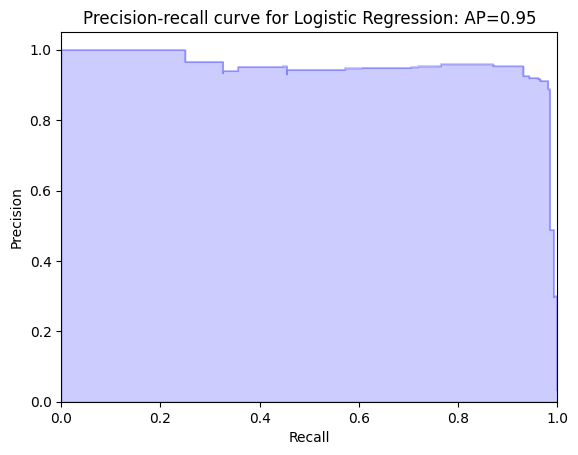

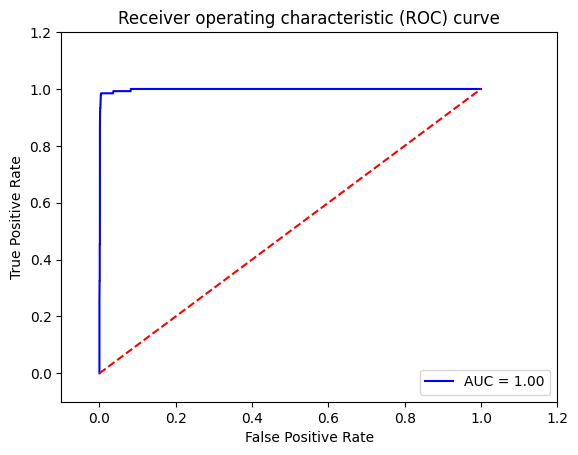

In [ ]:
## Step 6) Visualize SVM performance by precision-recall curve, and Receiver Operating Characterization (ROC) curve:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, auc
import matplotlib.pyplot as plt

## Plot the precision-recall curve for the SVM classifier:
labels_score         = svm.decision_function(features_test)
labels_test2         = [[int(y) for y in x] for x in labels_test]
precision, recall, _ = precision_recall_curve(labels_test2, labels_score)
average_precision    = average_precision_score(labels_test2, labels_score) ## Compute average precision-recall for SVM:

plt.figure(1)
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-recall curve for Logistic Regression: AP={0:0.2f}'.format(average_precision))

## Plot the Receiver Operating Characterization (ROC) curve for the SVM classifier:
false_positive_rate, true_positive_rate, thresholds = roc_curve(labels_test2, labels_score)
roc_auc = auc(false_positive_rate, true_positive_rate)

plt.figure(2)
plt.title('Receiver operating characteristic (ROC) curve')
plt.plot(false_positive_rate, true_positive_rate, 'b', label='AUC = %0.2f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.1,1.2])
plt.ylim([-0.1,1.2])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')


In [ ]:
## Step 7) Apply the Gaussian Naive Bayes (GNB) to predict labels of the test dataset ('email_test.csv').
## It is found by trial and error that GNB has the most accurate performance for generalization. The
## test emails and their predicted labels will be saved into 'solution.csv'.
## Import the unlabelled emails into python 3.6.1 using Pandas:

import pandas as pd
import numpy as np # Ensure numpy is imported
from sklearn.naive_bayes import GaussianNB # Import GaussianNB

df = pd.read_csv('email_test.csv', header=None, usecols=[0])
emails_test    = df.loc[:,0]
test_num       = len(emails_test)
features_test2 = np.zeros((test_num,7))

for i in range(0,test_num):
    features_test2[i,:] = np.array([feature_1(emails_test[i]),feature_2(emails_test[i]),feature_3(emails_test[i]),feature_4(emails_test[i]),feature_5(emails_test[i]),feature_6(emails_test[i]),feature_7(emails_test[i])])

# Instantiate and train the Gaussian Naive Bayes classifier
gnb = GaussianNB()
svm.fit(features, labels) # Train on the full training dataset

labels_test2 = svm.predict(features_test2)  # Predict labels of the test file

## Write the emails and the predicted labels into the csv file:
df = pd.DataFrame({'email_test':emails_test, 'label_test':labels_test2})
df.to_csv('solution.csv', encoding='utf-8', index=False)        # save emails and their predicted labels into 'solution.csv'.
